# SGD Finds Support — Visualization
Reads all runs from `output_dir` and plots **W1** and **Gram(W1)** for each model.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## Config
Change `OUTPUT_DIR` and `TRAJ_IDX` as needed.

In [3]:
OUTPUT_DIR = "outputs/linear"   # path to the folder with .npz + _config.json files
TRAJ_IDX   = 0                  # which trajectory to visualize (0 = first)
LAYER_IDX  = 0                  # which layer to use as W1 (0 = first hidden layer)

## Load all runs

In [4]:
def make_label(cfg):
    opt = cfg["optimizer"].upper()
    wd  = f" wd={cfg['weight_decay']}" if cfg["weight_decay"] != 0.0 else ""
    bs  = f" bs={cfg['batch_size']}"   if cfg["optimizer"] != "gd"    else ""
    return f"{opt}{bs}{wd}"

runs = []
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if not fname.endswith(".npz"):
        continue
    run_name   = fname[:-4]
    npz_path   = os.path.join(OUTPUT_DIR, fname)
    cfg_path   = os.path.join(OUTPUT_DIR, f"{run_name}_config.json")

    data = np.load(npz_path)
    with open(cfg_path) as f:
        cfg = json.load(f)

    t, l = TRAJ_IDX, LAYER_IDX
    runs.append({
        "label":       make_label(cfg),
        "run_name":    run_name,
        "cfg":         cfg,
        "W1_init":     data[f"traj{t}_layer{l}_init"],
        "W1_post":     data[f"traj{t}_layer{l}_post"],
        "losses":      data[f"traj{t}_losses"],
        "irelnorms":   data[f"traj{t}_irelnorms"],
    })

print(f"Loaded {len(runs)} runs:")
for r in runs:
    print(f"  {r['label']:25s}  W1 shape={r['W1_post'].shape}  n_iters={len(r['losses'])}  final_loss={r['losses'][-1]:.4f}  final_mse")

Loaded 7 runs:
  ADAM bs=512                W1 shape=(15, 15)  n_iters=200000  final_loss=0.0004  final_mse
  ADAMW bs=512               W1 shape=(15, 15)  n_iters=200000  final_loss=0.0004  final_mse
  GD                         W1 shape=(15, 15)  n_iters=200000  final_loss=0.0333  final_mse
  GD wd=0.1                  W1 shape=(15, 15)  n_iters=200000  final_loss=0.0009  final_mse
  MUON bs=512                W1 shape=(15, 15)  n_iters=200000  final_loss=0.4082  final_mse
  SGD bs=32                  W1 shape=(15, 15)  n_iters=200000  final_loss=0.0228  final_mse
  SGD bs=512                 W1 shape=(15, 15)  n_iters=200000  final_loss=0.0390  final_mse


In [5]:
# Reorder by label for better visualization
order = ["GD", "SGD bs=512", "SGD bs=32", "ADAM bs=512", "ADAMW bs=512", "MUON bs=512", "GD wd=0.1"]
runs = sorted(runs, key=lambda r: order.index(r["label"]))

## W1 (post-training) — all models

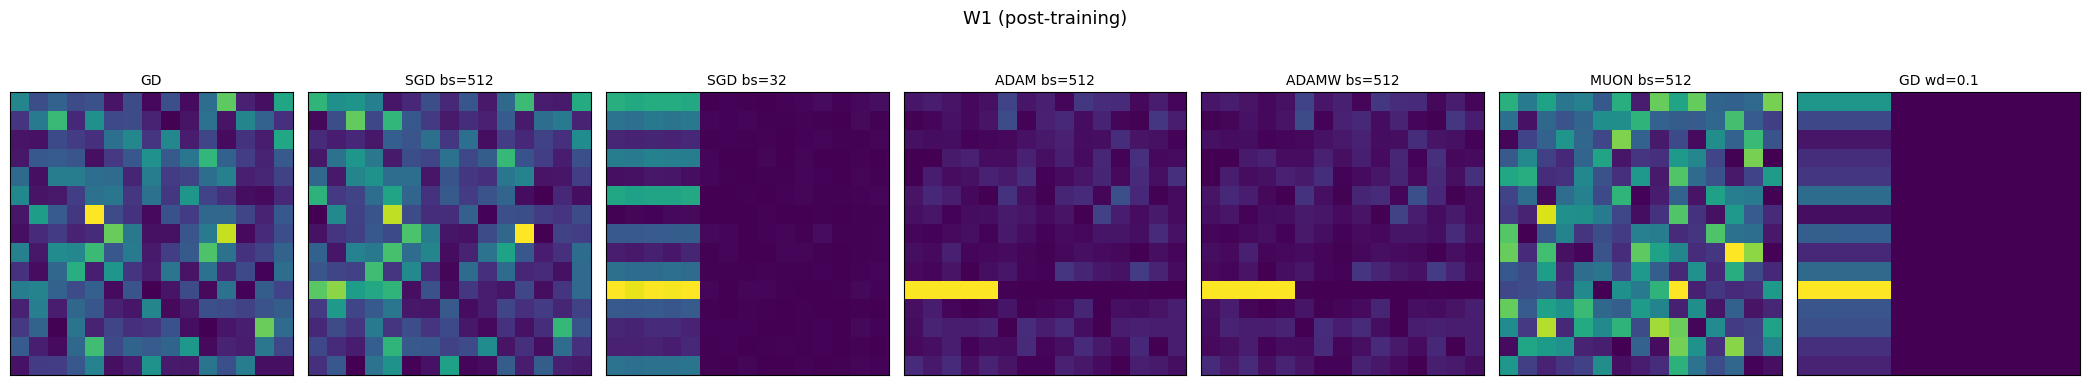

In [6]:
n = len(runs)
fig, axs = plt.subplots(1, n, figsize=(3 * n, 4))
if n == 1:
    axs = [axs]

for ax, r in zip(axs, runs):
    ax.imshow(np.abs(r["W1_post"]), cmap="viridis", interpolation="nearest")
    ax.set_title(r["label"], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("W1 (post-training)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Gram matrix of W1 — all models
Gram = |W1ᵀ W1|, normalized with min-max + γ=0.95 (same as sgd-support notebooks).

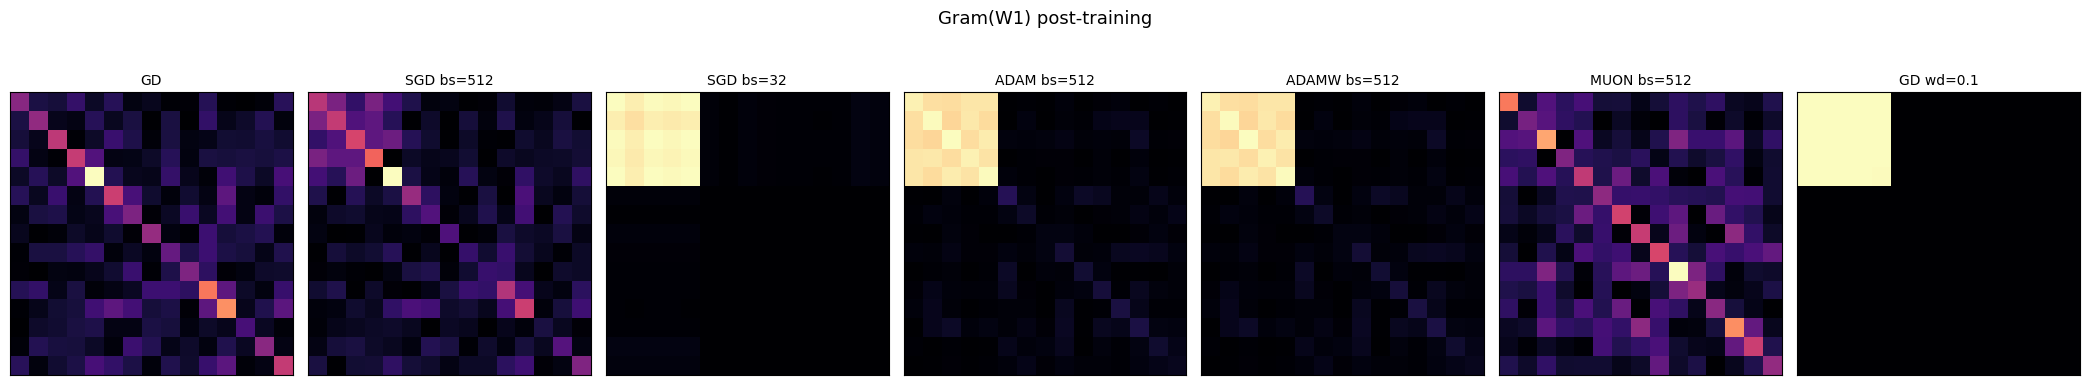

In [7]:
def gram(W):
    return np.abs(W.T @ W)

def minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

grams = [minmax(gram(r["W1_post"]) ** 0.95) for r in runs]
vmin  = min(g.min() for g in grams)
vmax  = max(g.max() for g in grams)

fig, axs = plt.subplots(1, n, figsize=(3 * n, 4))
if n == 1:
    axs = [axs]

for ax, g, r in zip(axs, grams, runs):
    im = ax.imshow(g, cmap="magma", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_title(r["label"], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# fig.colorbar(im, ax=axs, shrink=0.7)
fig.suptitle("Gram(W1) post-training", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## W1 init vs post — side by side

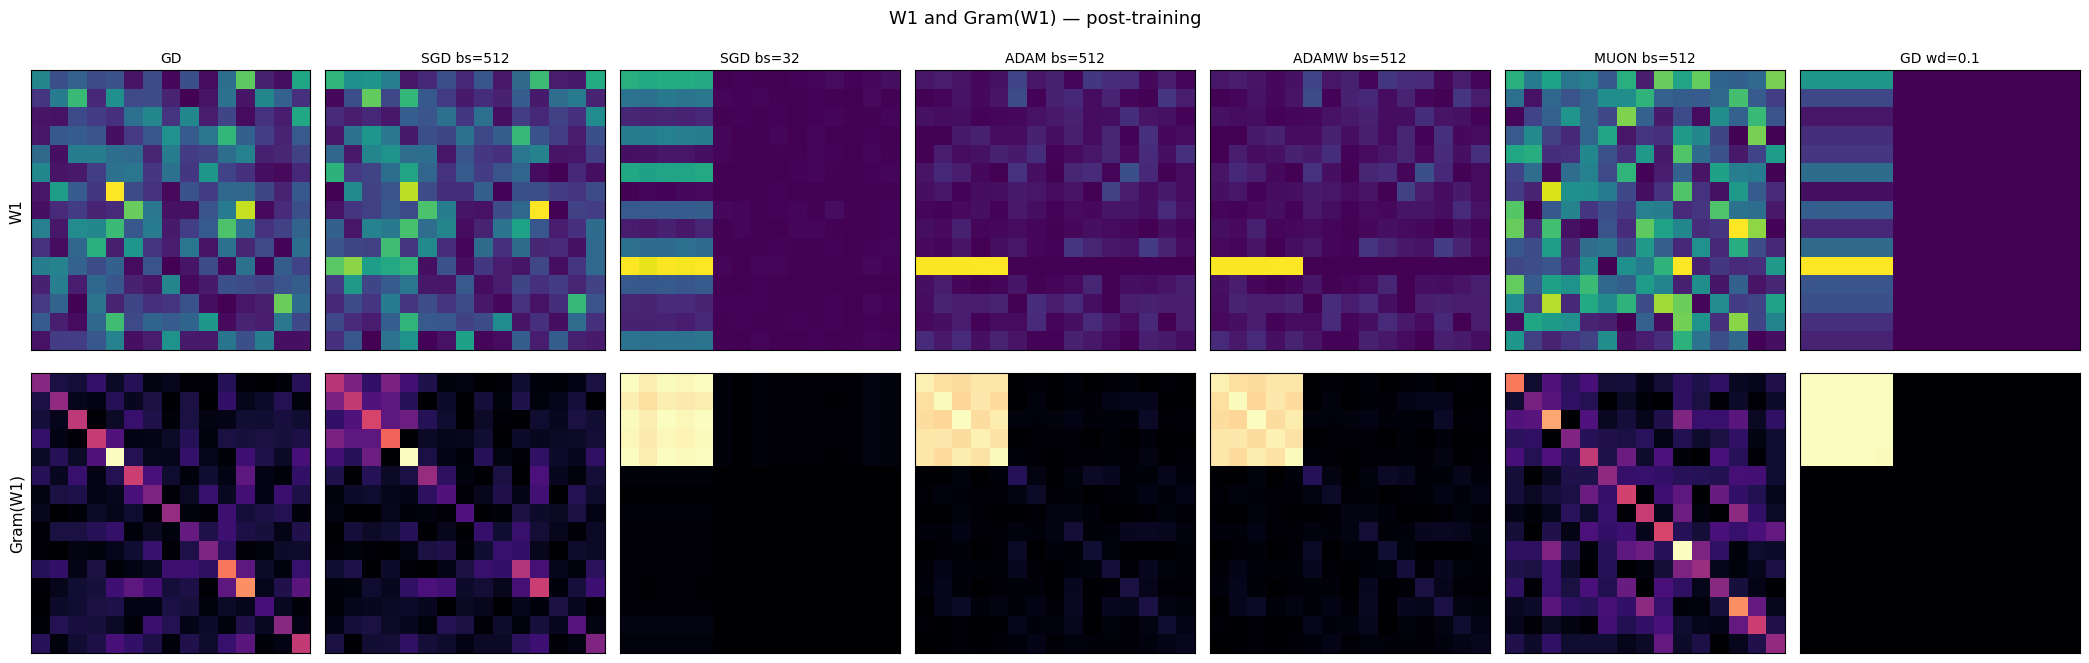

In [8]:
fig, axs = plt.subplots(2, n, figsize=(3 * n, 7))
if n == 1:
    axs = axs[:, np.newaxis]

grams_post = [minmax(gram(r["W1_post"]) ** 0.95) for r in runs]
vmin = min(g.min() for g in grams_post)
vmax = max(g.max() for g in grams_post)

for i, r in enumerate(runs):
    # row 0 — W1
    axs[0, i].imshow(np.abs(r["W1_post"]), cmap="viridis", interpolation="nearest")
    axs[0, i].set_title(r["label"], fontsize=10)
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])

    # row 1 — Gram(W1)
    im = axs[1, i].imshow(grams_post[i], cmap="magma", interpolation="nearest", vmin=vmin, vmax=vmax)
    axs[1, i].set_xticks([])
    axs[1, i].set_yticks([])

axs[0, 0].set_ylabel("W1", fontsize=11)
axs[1, 0].set_ylabel("Gram(W1)", fontsize=11)
# fig.colorbar(im, ax=axs[1, :].tolist(), shrink=0.7, label="normalized")
fig.suptitle("W1 and Gram(W1) — post-training", fontsize=13)
plt.tight_layout()
plt.show()

## Training curves

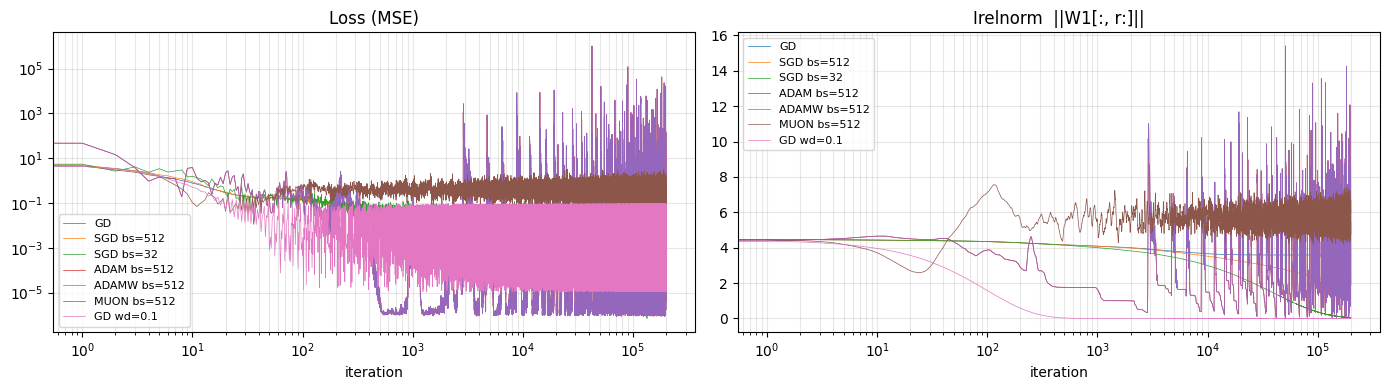

In [9]:
from pdb import run


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for r in runs:
    ax1.loglog(r["losses"],    label=r["label"], linewidth=.5)
    mse = r["losses"][-1]
    ax1.set_title(f"{r['label']}  (MSE={mse:.4f})", fontsize=10)
    ax2.semilogx(r["irelnorms"], label=r["label"], linewidth=.5)

ax1.set_title("Loss (MSE)")
ax1.set_xlabel("iteration")
ax1.legend(fontsize=8)
ax1.grid(True, which="both", alpha=0.3)

ax2.set_title("Irelnorm  ||W1[:, r:]||")
ax2.set_xlabel("iteration")
ax2.legend(fontsize=8)
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

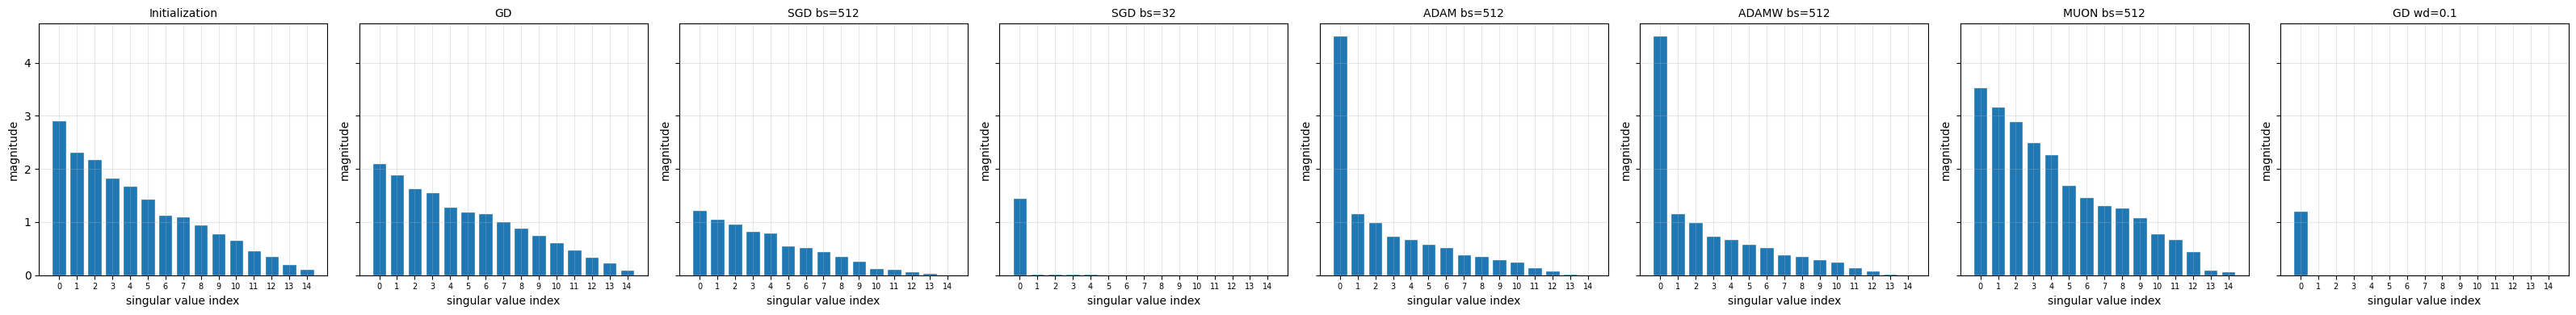

In [10]:
fig, axs = plt.subplots(1, len(runs) + 1, figsize=(4 * (len(runs) + 1), 4), sharey=True, sharex=True)

def plot_sv_hist(ax, W, title):
    svs = np.linalg.svd(W, compute_uv=False)
    ax.bar(range(len(svs)), svs, edgecolor="white")
    # ax.axhline(np.median(svs), color="red",    linestyle="dotted", linewidth=1.5)
    # ax.axhline(np.mean(svs),   color="orange", linestyle="dashed",  linewidth=1.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("singular value index")
    ax.set_ylabel("magnitude")
    ax.set_xticks(range(len(svs)))
    ax.set_xticklabels(range(len(svs)), fontsize=7)
    ax.grid(True, which="both", alpha=0.3)

plot_sv_hist(axs[0], runs[0]["W1_init"], "Initialization")

for i, r in enumerate(runs):
    plot_sv_hist(axs[i + 1], r["W1_post"], r["label"])

plt.tight_layout()
plt.show()

In [11]:
for run in runs:
    print(f"{run['label']:25s}  MSE final = {run['losses'][-1]:.6f}")

GD                         MSE final = 0.033273
SGD bs=512                 MSE final = 0.039014
SGD bs=32                  MSE final = 0.022793
ADAM bs=512                MSE final = 0.000429
ADAMW bs=512               MSE final = 0.000429
MUON bs=512                MSE final = 0.408194
GD wd=0.1                  MSE final = 0.000893
